<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/cat_v_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/


In [2]:
! kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:08<00:00, 134MB/s]



In [3]:
# unzip the file
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [13]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from keras import Sequential
from keras.preprocessing  import image
from PIL import Image
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout



In [9]:
augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.15),

    tf.keras.layers.RandomZoom(0.20),

    tf.keras.layers.RandomContrast(0.20),

    tf.keras.layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),

    tf.keras.layers.RandomBrightness(0.20)
])

In [10]:
input_dir = "/content/train"

output_dir = "/content/augmented_train"

os.makedirs(output_dir, exist_ok=True)

In [11]:
# paramter of image
IMAGE_SIZE = (224,224)

NUM_AUGMENTED = 5

In [14]:
# Augment Entire Dataset
for class_name in os.listdir(input_dir):
    input_class = os.path.join(input_dir, class_name)
    if not os.path.isdir(input_class):
        continue

    output_class = os.path.join(output_dir, class_name)
    os.makedirs(output_class, exist_ok=True)
    print(f"\nProcessing {class_name}")
    count=0

    for file_name in os.listdir(input_class):
        image_path = os.path.join(input_class, file_name)

        try:
          image=Image.open(image_path)
          image=image.resize(IMAGE_SIZE)
          image_np=np.array(image)
          image_tensor=tf.expand_dims(image_np,axis=0)

          # save original
          image.save(os.path.join(output_class,file_name))
          name=os.path.splittext(file_name)[0]
          # generate augmented images

          for i in range(NUM_AUGMENTED):
            augmented_image=augmentation(image_tensor)

            aug=tf.squeeze(aug)
            aug=tf.clip_by_value(aug,0,255)
            aug=tf.cast(aug,tf.uint8)
            Image.fromarray(
                    aug.numpy()
                ).save(

                    os.path.join(
                        output_class,
                        f"{name}_aug_{i}.jpg"
                    )

                )
            count+=1
            if count % 500 == 0:
                print(f"{count} images processed")


        except  Exception as e:
          print(image_path)
          print(e)



Streaming output truncated to the last 5000 lines.
/content/train/cats/cat.10318.jpg
module 'posixpath' has no attribute 'splittext'
/content/train/cats/cat.4407.jpg
module 'posixpath' has no attribute 'splittext'
/content/train/cats/cat.2243.jpg
module 'posixpath' has no attribute 'splittext'
/content/train/cats/cat.4995.jpg
module 'posixpath' has no attribute 'splittext'
/content/train/cats/cat.5223.jpg
module 'posixpath' has no attribute 'splittext'
/content/train/cats/cat.1702.jpg
module 'posixpath' has no attribute 'splittext'
/content/train/cats/cat.8641.jpg
module 'posixpath' has no attribute 'splittext'
/content/train/cats/cat.3424.jpg
module 'posixpath' has no attribute 'splittext'
/content/train/cats/cat.8630.jpg
module 'posixpath' has no attribute 'splittext'
/content/train/cats/cat.2864.jpg
module 'posixpath' has no attribute 'splittext'
/content/train/cats/cat.10758.jpg
module 'posixpath' has no attribute 'splittext'
/content/train/cats/cat.4536.jpg
module 'posixpath' has 

In [15]:
for class_name in os.listdir(output_dir):

    folder = os.path.join(output_dir, class_name)

    print(class_name, len(os.listdir(folder)))

dogs 10000
cats 10000


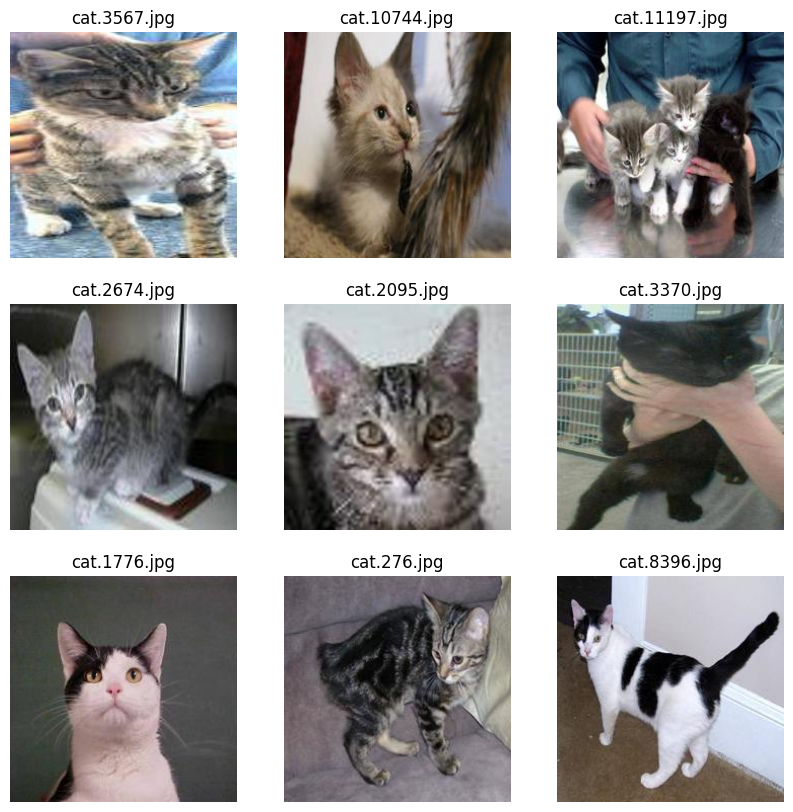

In [16]:
import matplotlib.pyplot as plt

folder = os.path.join(output_dir, "cats")

images = os.listdir(folder)[:9]

plt.figure(figsize=(10,10))

for i, img_name in enumerate(images):

    img = Image.open(os.path.join(folder, img_name))

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(img_name)

    plt.axis("off")

plt.show()

In [17]:
# genrator
train_ds=keras.utils.image_dataset_from_directory(directory='/content/augmented_train',labels='inferred',label_mode='int',batch_size=32,image_size=(256,256))
validation_ds=keras.utils.image_dataset_from_directory(directory='/content/test',labels='inferred',label_mode='int',batch_size=32, image_size=(256,256))


Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [18]:
# Normalize image size from 0 to 1 range
def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [19]:
# Create CNN model
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [22]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 93ms/step - accuracy: 0.6088 - loss: 2.2224 - val_accuracy: 0.6934 - val_loss: 1.2136
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.7232 - loss: 0.9303 - val_accuracy: 0.7266 - val_loss: 0.8262
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.7649 - loss: 0.7667 - val_accuracy: 0.7312 - val_loss: 0.7806
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 90ms/step - accuracy: 0.7958 - loss: 0.6929 - val_accuracy: 0.7740 - val_loss: 0.7582
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.8168 - loss: 0.7642 - val_accuracy: 0.8156 - val_loss: 0.8242
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.8383 - loss: 0.7482 - val_accuracy: 0.7636 - val_loss: 0.9869
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8561 - loss: 0.8421 - val_accuracy: 0.7744 - val_loss: 1.0570
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.8800 - loss: 0.8299 - 

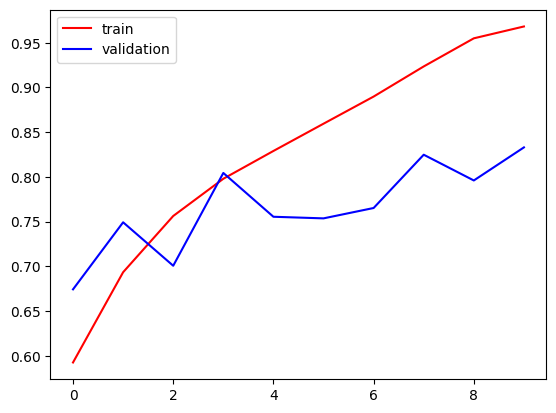

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()
#


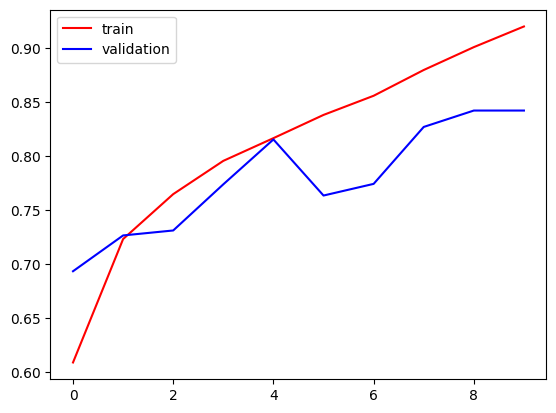

In [23]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()
#

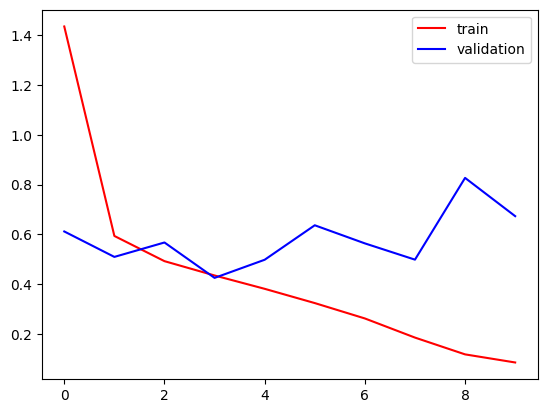

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()


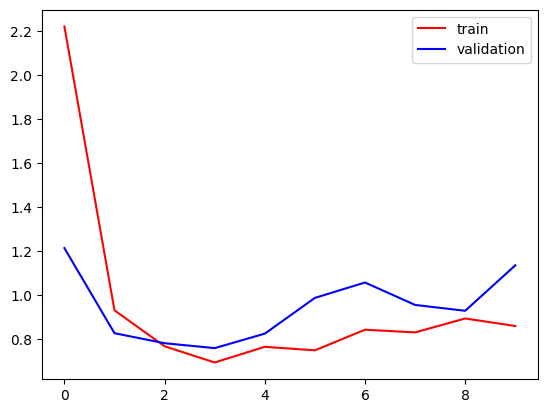

In [24]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

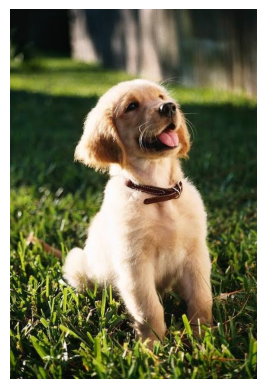

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Raw Prediction Value: 0.9702744483947754
Prediction: It's a DOG!


In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
image_path = '/content/dog.jpg'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] < 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")
else:
    print(f"Image not found at {image_path}. Please check your path.")
